In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

plt.style.use('default')
sns.set_theme()

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


np.int64(0)

Rows : 2640
Columns : 12


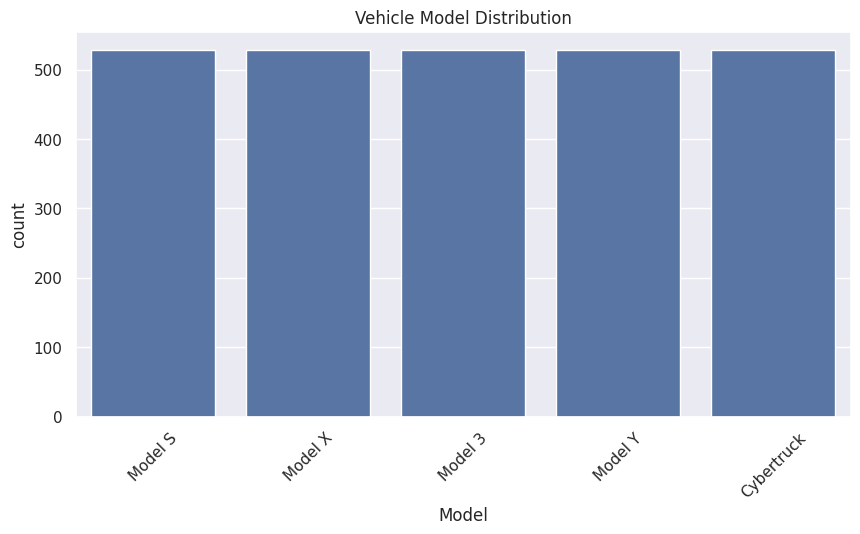

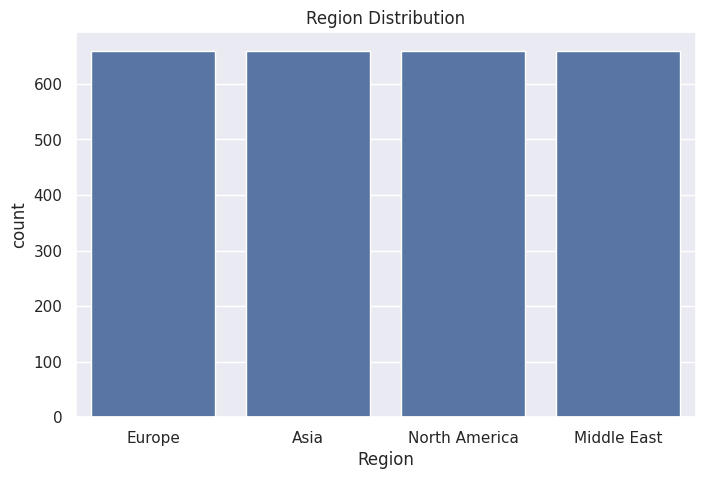

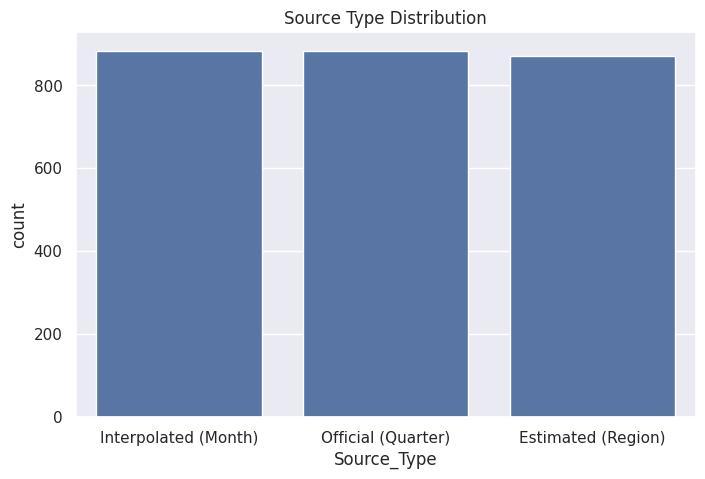

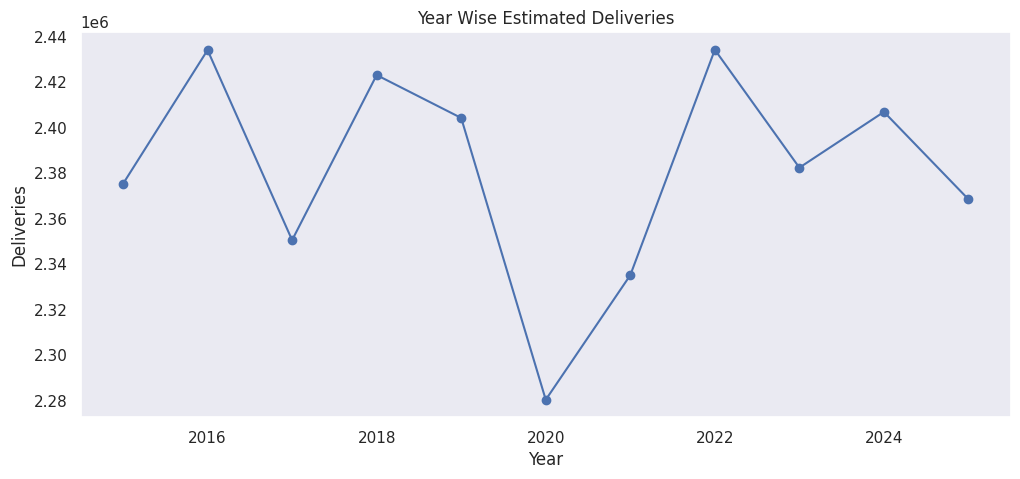

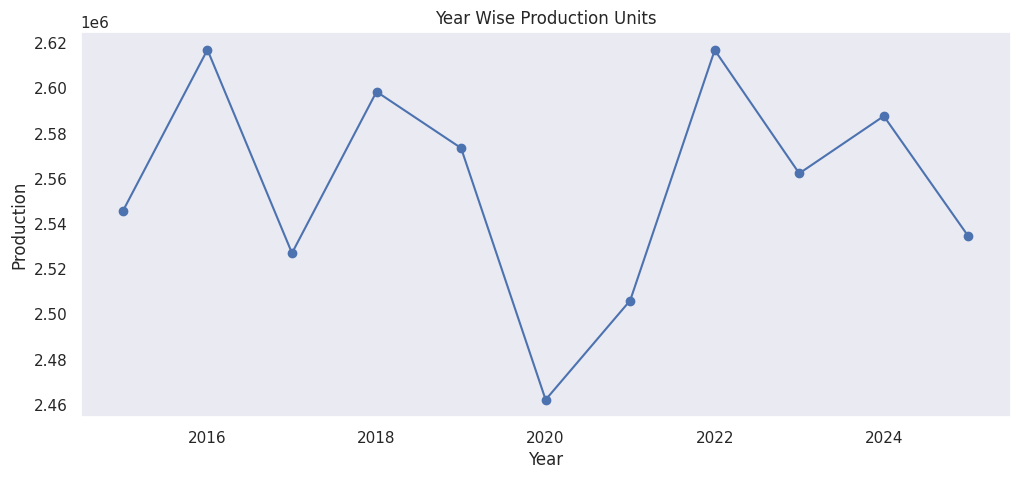

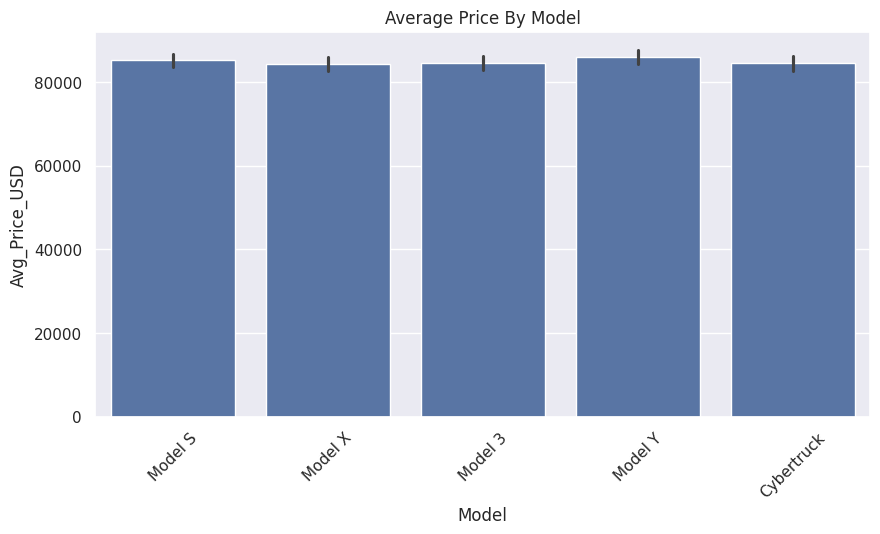

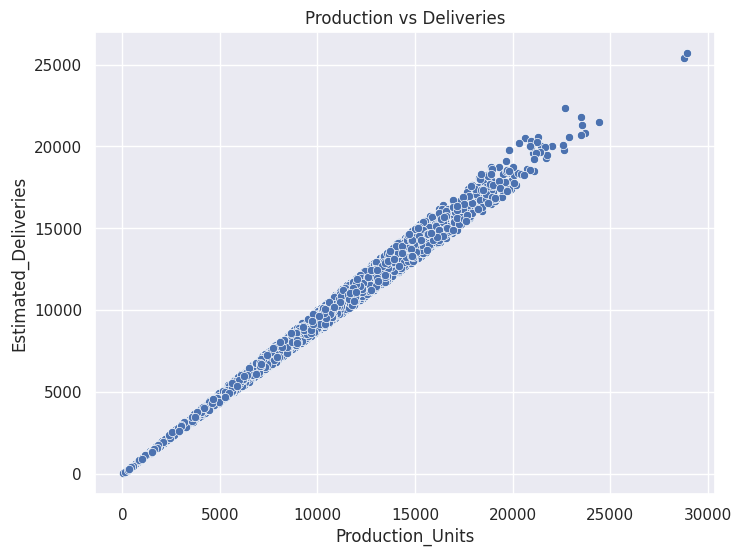

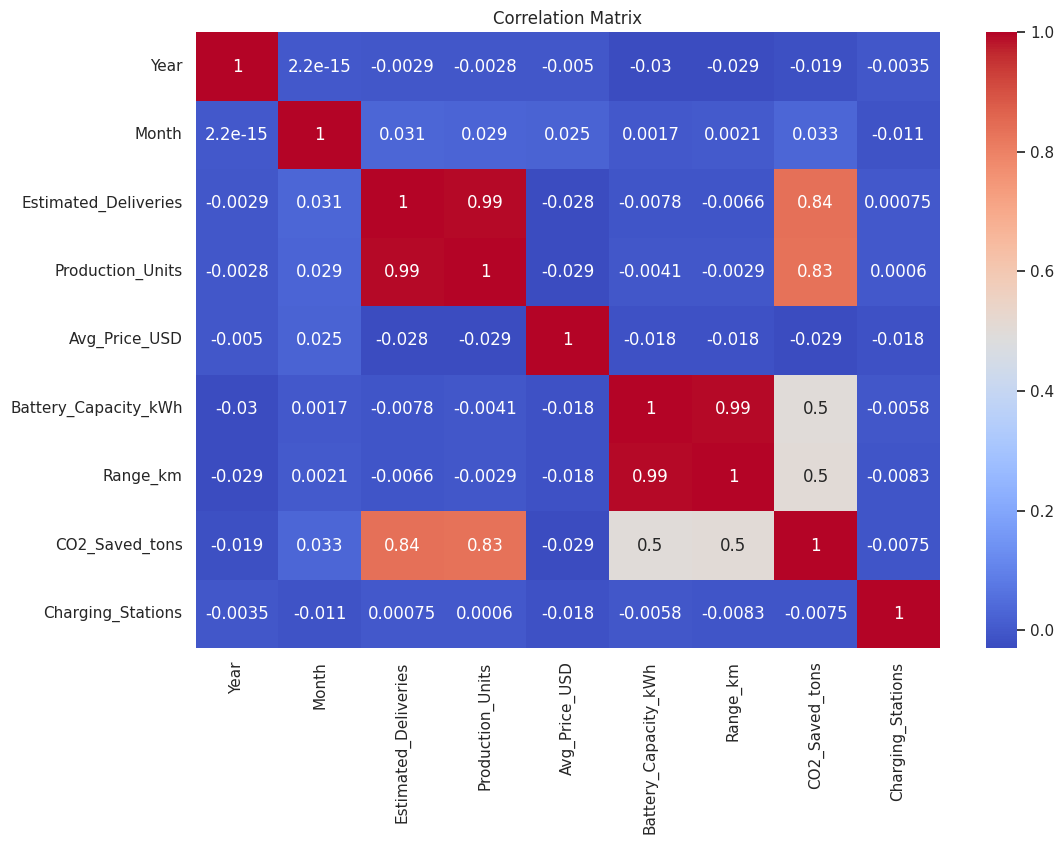

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Model'
)

plt.title('Vehicle Model Distribution')

plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Region'
)

plt.title('Region Distribution')

plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Source_Type'
)

plt.title('Source Type Distribution')

plt.show()
yearly_deliveries = df.groupby(
    'Year'
)['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))

plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker='o'
)

plt.title('Year Wise Estimated Deliveries')

plt.xlabel('Year')

plt.ylabel('Deliveries')

plt.grid()

plt.show()
yearly_production = df.groupby(
    'Year'
)['Production_Units'].sum()

plt.figure(figsize=(12,5))

plt.plot(
    yearly_production.index,
    yearly_production.values,
    marker='o'
)

plt.title('Year Wise Production Units')

plt.xlabel('Year')

plt.ylabel('Production')

plt.grid()

plt.show()
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Model',
    y='Avg_Price_USD'
)

plt.title('Average Price By Model')

plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title('Production vs Deliveries')

plt.show()
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

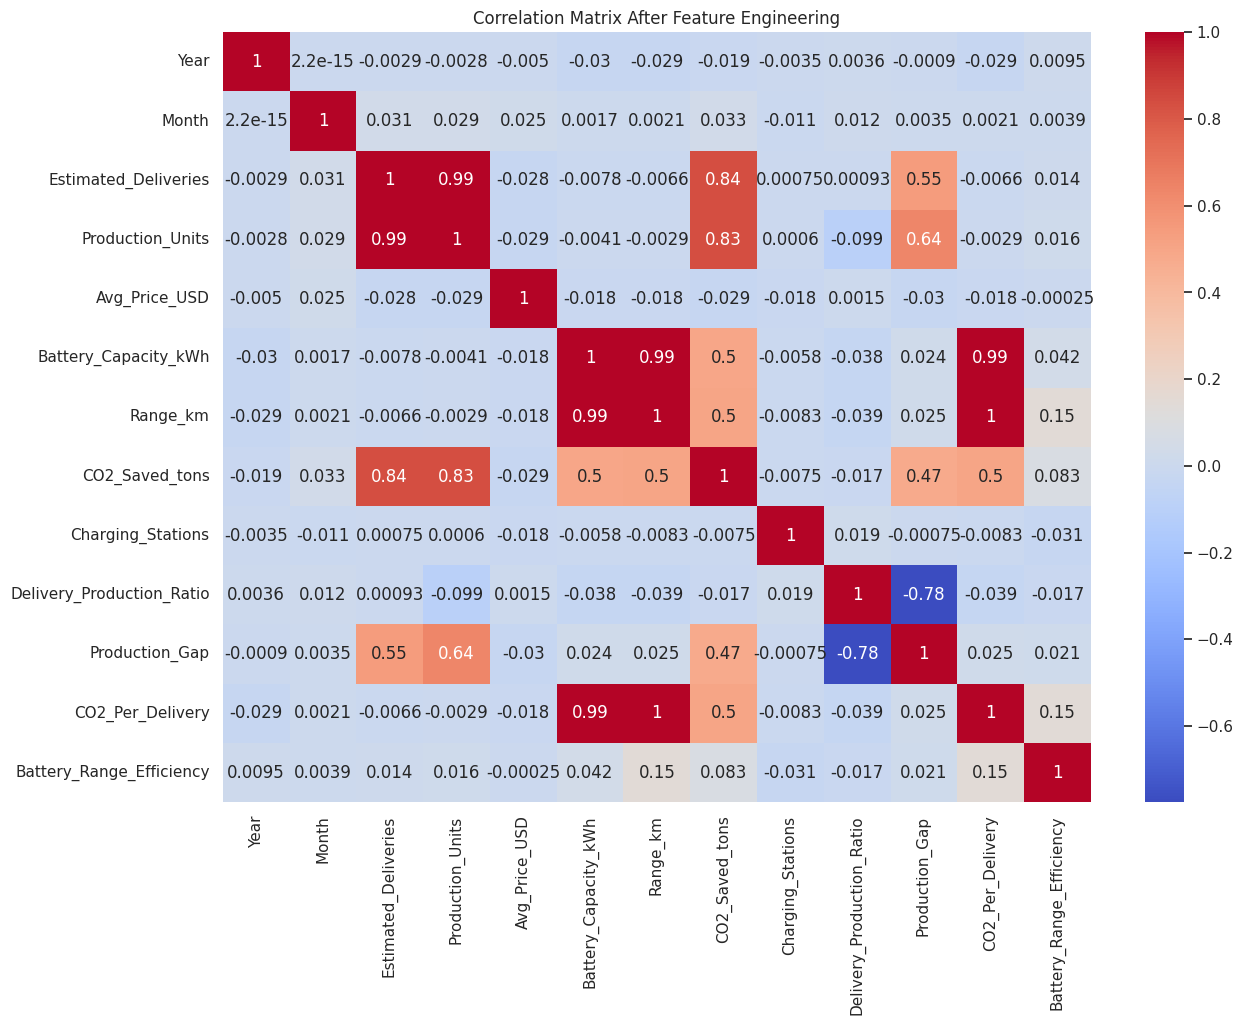

In [6]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) +
    '-' +
    df['Month'].astype(str)
)
df['Delivery_Production_Ratio'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)
df['Production_Gap'] = (
    df['Production_Units']
    -
    df['Estimated_Deliveries']
)
df['CO2_Per_Delivery'] = (
    df['CO2_Saved_tons']
    /
    df['Estimated_Deliveries']
)
df['Battery_Range_Efficiency'] = (
    df['Range_km']
    /
    df['Battery_Capacity_kWh']
)
df.head()
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix After Feature Engineering')

plt.show()

In [7]:
X = df.drop(
    columns=[
        'Avg_Price_USD',
        'Date'
    ]
)

y = df['Avg_Price_USD']

print(X.shape)
print(y.shape)
categorical_features = [
    'Region',
    'Model',
    'Source_Type'
]

numerical_features = [
    col
    for col in X.columns
    if col not in categorical_features
]

print(categorical_features)
print(numerical_features)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)
linear_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            LinearRegression()
        )
    ]
)
linear_pipeline.fit(
    X_train,
    y_train
)
linear_pred = linear_pipeline.predict(
    X_test
)
print(
    "R2 Score :",
    r2_score(
        y_test,
        linear_pred
    )
)

print(
    "MAE :",
    mean_absolute_error(
        y_test,
        linear_pred
    )
)

print(
    "RMSE :",
    np.sqrt(
        mean_squared_error(
            y_test,
            linear_pred
        )
    )
)
rf_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            RandomForestRegressor(
                random_state=42,
                n_estimators=300
            )
        )
    ]
)
rf_pipeline.fit(
    X_train,
    y_train
)
rf_pred = rf_pipeline.predict(
    X_test
)
print(
    "R2 Score :",
    r2_score(
        y_test,
        rf_pred
    )
)

print(
    "MAE :",
    mean_absolute_error(
        y_test,
        rf_pred
    )
)

print(
    "RMSE :",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )
)

(2640, 15)
(2640,)
['Region', 'Model', 'Source_Type']
['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Delivery_Production_Ratio', 'Production_Gap', 'CO2_Per_Delivery', 'Battery_Range_Efficiency']
(2112, 15)
(528, 15)
R2 Score : -0.009615225457849208
MAE : 16802.381551119626
RMSE : 19512.52827858196
R2 Score : -0.06688596142578662
MAE : 17083.978213068174
RMSE : 20058.322057119974


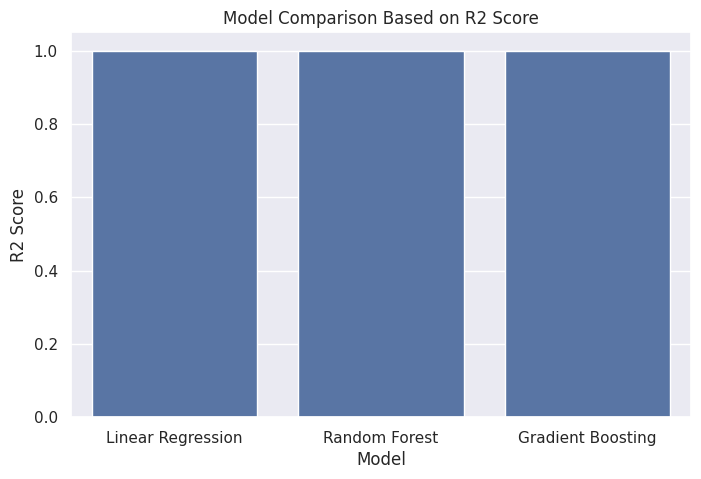

,Model,R2 Score,MAE,RMSE
0,Linear Regression,1.000000,2.176328e-11,2.547366e-11
2,Gradient Boosting,0.999359,7.103215e+01,9.778226e+01
1,Random Forest,0.999199,6.601887e+01,1.092500e+02


In [8]:
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df['Estimated_Deliveries']

categorical_features = [
    'Region',
    'Model',
    'Source_Type'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

linear_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

rf_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            RandomForestRegressor(
                n_estimators=500,
                random_state=42
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

gb_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(
    X_test
)

gb_r2 = r2_score(
    y_test,
    gb_pred
)

gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)

results = pd.DataFrame(
    {
        'Model': [
            'Linear Regression',
            'Random Forest',
            'Gradient Boosting'
        ],
        'R2 Score': [
            linear_r2,
            rf_r2,
            gb_r2
        ],
        'MAE': [
            linear_mae,
            rf_mae,
            gb_mae
        ],
        'RMSE': [
            linear_rmse,
            rf_rmse,
            gb_rmse
        ]
    }
)

results.sort_values(
    by='R2 Score',
    ascending=False
)
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title(
    'Model Comparison Based on R2 Score'
)

plt.show()
results = results.sort_values(
    by='R2 Score',
    ascending=False
)

results

In [9]:
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df['Estimated_Deliveries']

categorical_features = [
    'Region',
    'Model',
    'Source_Type'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

param_grid = {

    'model__n_estimators':[100,300,500],

    'model__max_depth':[10,20,30],

    'model__min_samples_split':[2,5,10]

}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(grid_search.best_params_)

best_model = grid_search.best_estimator_

predictions = best_model.predict(
    X_test
)

print(
    "Tuned R2 Score:",
    r2_score(
        y_test,
        predictions
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
)

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Tuned R2 Score: 0.999218443378746
MAE: 66.37135101010098
RMSE: 107.93566690075045


          Date  Forecast_Deliveries
132 2026-01-31        203819.655291
133 2026-02-28        202894.176208
134 2026-03-31        199011.662577
135 2026-04-30        198667.010489
136 2026-05-31        200971.493839
137 2026-06-30        201391.449843
138 2026-07-31        201412.663910
139 2026-08-31        201031.409119
140 2026-09-30        200601.086701
141 2026-10-31        200710.068214
142 2026-11-30        200864.721560
143 2026-12-31        200936.680134


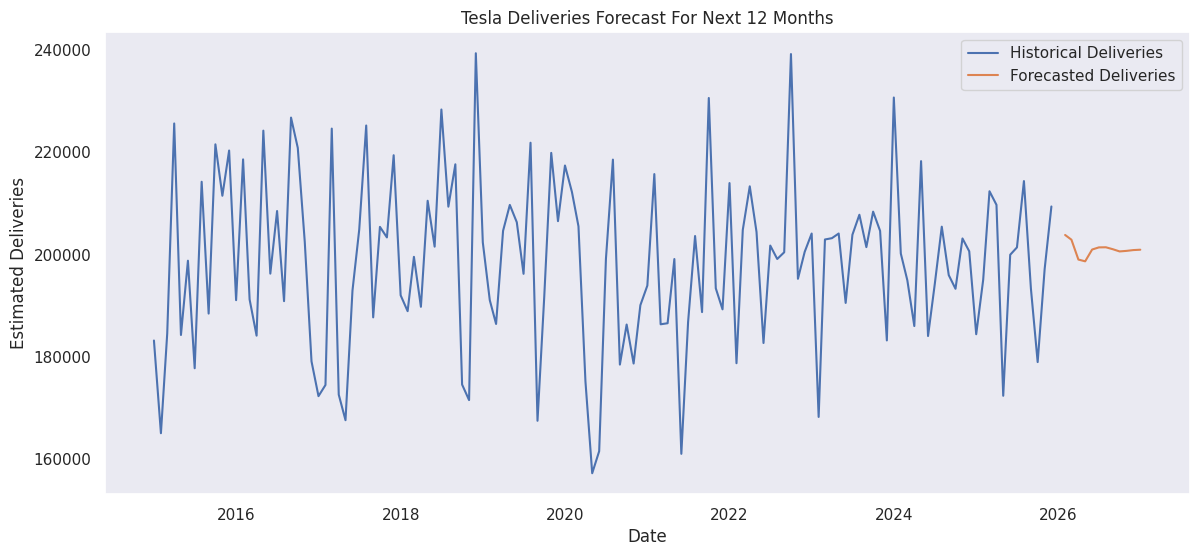

In [10]:
monthly_deliveries = df.groupby(
    ['Year', 'Month']
)['Estimated_Deliveries'].sum().reset_index()

monthly_deliveries['Date'] = pd.to_datetime(
    monthly_deliveries['Year'].astype(str)
    + '-'
    + monthly_deliveries['Month'].astype(str)
)

monthly_deliveries = monthly_deliveries.sort_values(
    'Date'
)

from statsmodels.tsa.arima.model import ARIMA

series = monthly_deliveries[
    'Estimated_Deliveries'
]

arima_model = ARIMA(
    series,
    order=(5,1,0)
)

arima_result = arima_model.fit()

forecast = arima_result.forecast(
    steps=12
)

forecast_dates = pd.date_range(
    start=monthly_deliveries['Date'].max(),
    periods=13,
    freq='M'
)[1:]

forecast_df = pd.DataFrame(
    {
        'Date': forecast_dates,
        'Forecast_Deliveries': forecast
    }
)

print(forecast_df)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_deliveries['Date'],
    monthly_deliveries['Estimated_Deliveries'],
    label='Historical Deliveries'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Deliveries'],
    label='Forecasted Deliveries'
)

plt.title(
    'Tesla Deliveries Forecast For Next 12 Months'
)

plt.xlabel('Date')

plt.ylabel('Estimated Deliveries')

plt.legend()

plt.grid()

plt.show()